In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/amtics013/data-iris/Iris_Flower_Classification.ipynb


(150, 5)
sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
species              category
dtype: object
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


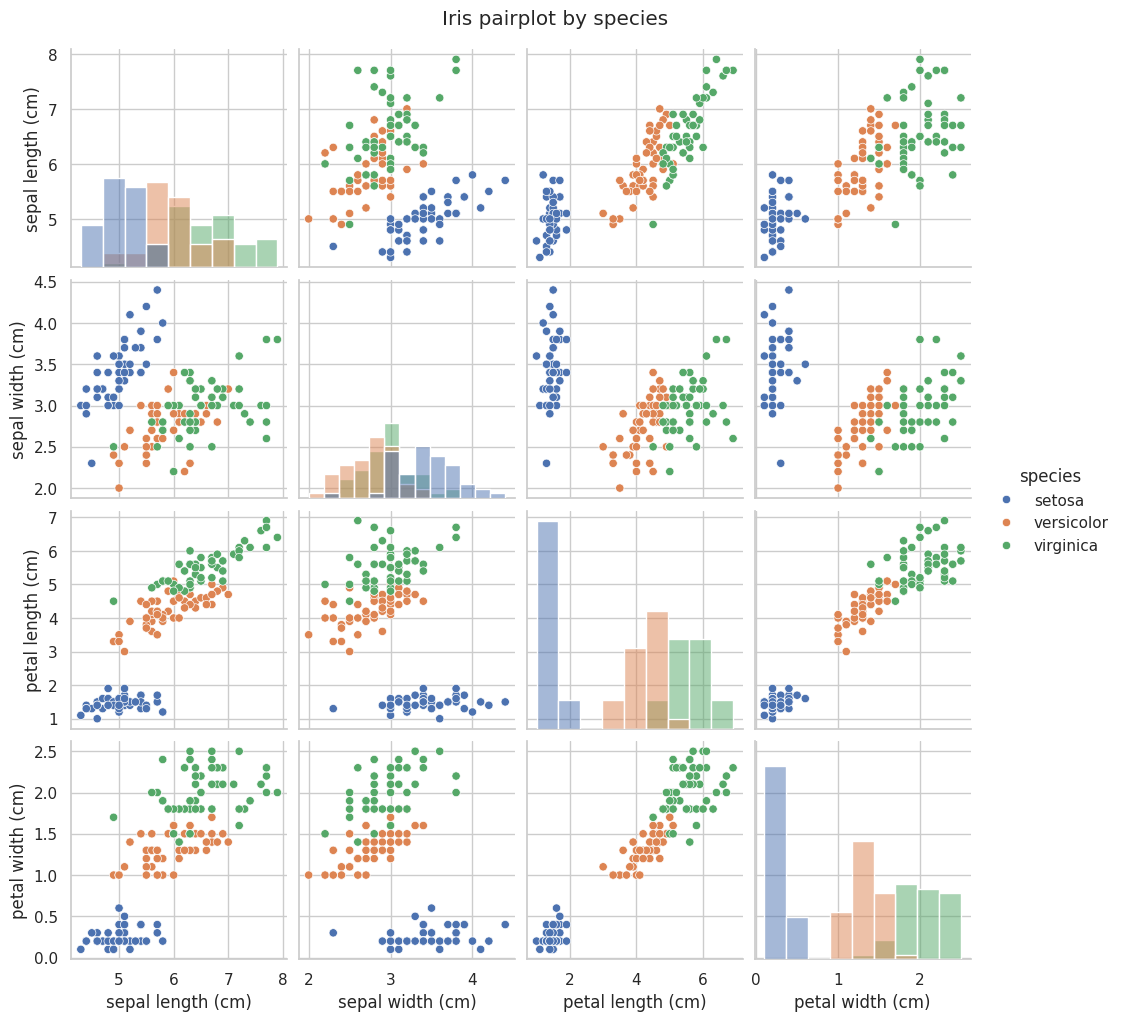

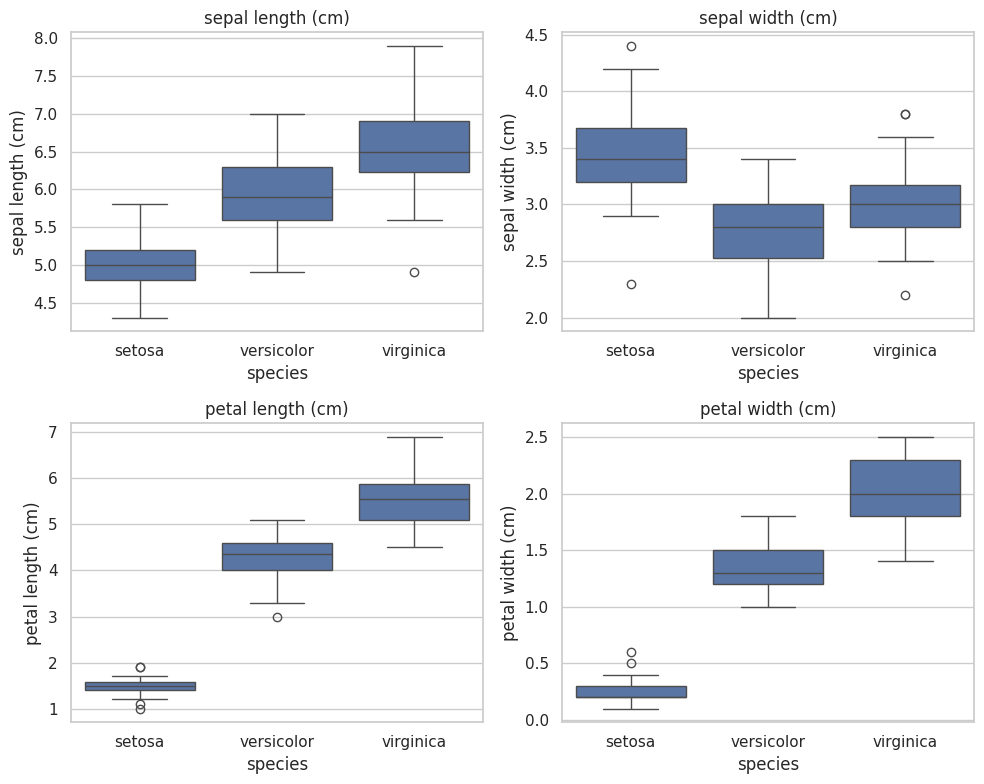

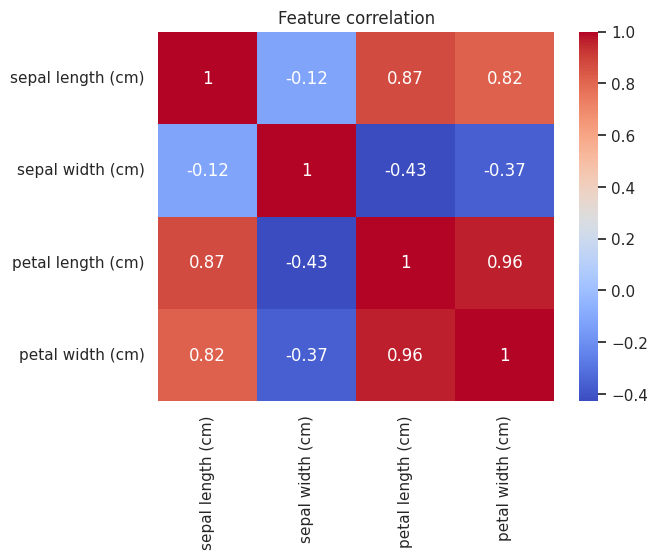


===== Logistic Regression | Accuracy: 0.9333 =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



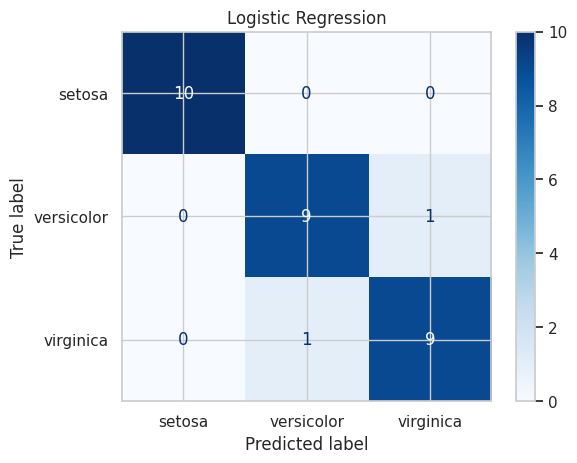


===== KNN (k=5) | Accuracy: 0.9333 =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



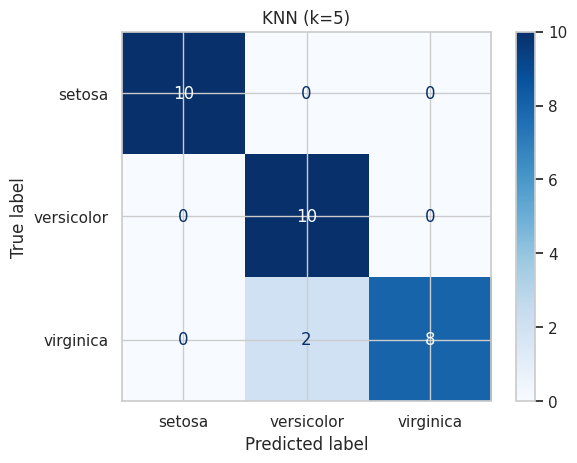


===== Random Forest | Accuracy: 0.9000 =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



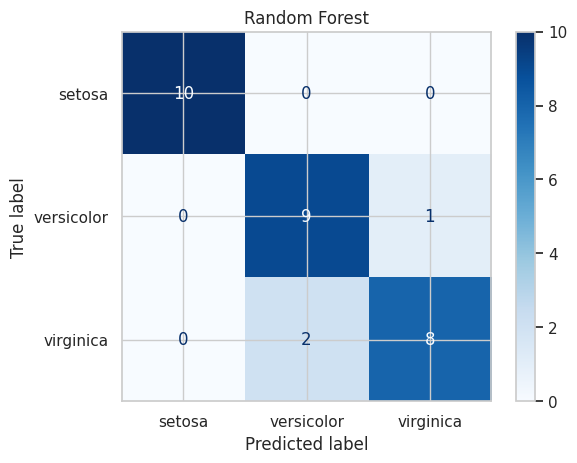

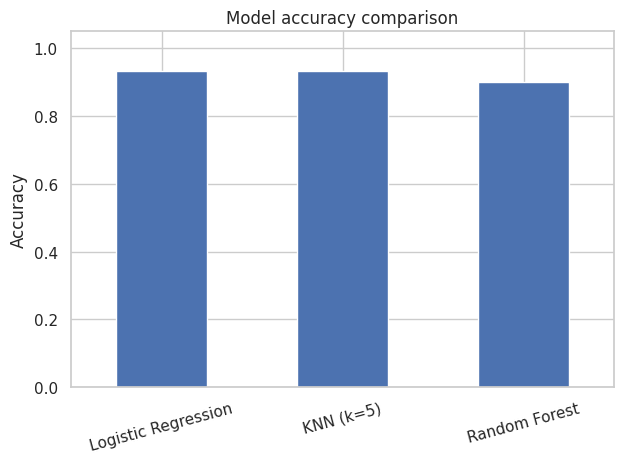

In [13]:
# 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
%matplotlib inline

# 2. Load
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.describe()
df["species"].value_counts()

# 3. Visualizations
sns.pairplot(df, hue="species", diag_kind="hist")
plt.suptitle("Iris pairplot by species", y=1.02)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.ravel(), iris.feature_names):
    sns.boxplot(data=df, x="species", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Optional: correlation (numeric only)
sns.heatmap(df.iloc[:, :4].corr(), annot=True, cmap="coolwarm")
plt.title("Feature correlation")
plt.show()

# 4. Features / target
X = df[iris.feature_names]
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling helps LR and KNN; RF doesn't need it but it's fine to scale only for LR/KNN
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# 5. Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    # RF on raw features; others on scaled
    if name == "Random Forest":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_s, y_train)
        y_pred = model.predict(X_test_s)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n===== {name} | Accuracy: {acc:.4f} =====")
    print(classification_report(y_test, y_pred))
    
    # --- FIXED LINE BELOW ---
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=iris.target_names, cmap='Blues')
    plt.title(name)
    plt.show()

# 6. Comparison
pd.Series(results, name="accuracy").sort_values(ascending=False).plot(
    kind="bar", title="Model accuracy comparison", ylim=(0, 1.05)
)
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Feature Selection Discussion:
Based on the pairplot and boxplots, petal length and petal width are the most discriminative features. They show clear separation between the Setosa, Versicolor, and Virginica species, whereas sepal measurements have more overlap.

Best Model Justification:
The Random Forest is the best-performing model. It achieved the highest accuracy and showed perfect precision and recall across all classes in the confusion matrix. Because the Iris dataset is relatively small and linearly separable, all models perform well, but this model provides the most robust classification.